## Experimentations
### Methods:
- IID
- CTE  
- CTE stratified with predictions and with real labeles (for a good model they are the same)
- CTE with predictions 

### Explanations:
- Kernel SHAP
- Permutation SAGE

In [75]:
import time
import numpy as np
import pandas as pd
import os
from tqdm import tqdm

from goodpoints import compress
from openxai.model import LoadModel
from openxai.dataloader import ReturnLoaders
import sage
import shap

np.random.seed(0)

data_name_german = 'german'
times_cte_info_path_german = f'../metadata/german/cte_shap_sage_times_0_3.csv'

data_name_compas = 'compas'
times_cte_info_path_compas = f'../metadata/compas/cte_shap_sage_times_0_3.csv'

### load calculated shap and sage explanations data for 'ann' model

In [76]:
times_cte_info_german = pd.read_csv(times_cte_info_path_german)
times_cte_info_german.head(10)

,dataset,repeat,method,time_explanation,time_sample_choose,n_original,n_sample,mmd,mae,top_k
0,german,0,cte_shap,26.798588,0.002758,200,8,0.004257,0.008514,0.0
1,german,0,cte_sage,69.186417,0.002758,200,8,0.004257,0.011909,0.2
2,german,0,iid_shap,26.575708,0.000956,200,8,0.015708,0.013060,0.0
3,german,0,iid_sage,41.287010,0.000956,200,8,0.015708,0.015805,0.2
4,german,0,cte_stratified_real_shap,38.560911,0.000285,200,12,0.003642,0.007681,0.0
5,german,0,cte_stratified_real_sage,86.045702,0.000285,200,12,0.003642,0.006081,0.4
6,german,0,cte_stratified_pred_shap,38.598514,0.000265,200,12,0.003516,0.007587,0.0
7,german,0,cte_stratified_pred_sage,108.624466,0.000265,200,12,0.003516,0.004221,0.4
8,german,0,cte_with_predictions_shap,27.310418,0.000203,200,8,0.004257,0.008520,0.0
9,german,0,cte_with_predictions_sage,71.519052,0.000203,200,8,0.004257,0.011909,0.2


In [77]:
times_cte_info_german['explanation'] = times_cte_info_german['method'].str.extract(r'_(shap|sage)')
times_cte_info_german['method'] = times_cte_info_german['method'].str.replace(r'_(shap|sage)', '', regex=True)
times_cte_info_german.head(3)

,dataset,repeat,method,time_explanation,time_sample_choose,n_original,n_sample,mmd,mae,top_k,explanation
0,german,0,cte,26.798588,0.002758,200,8,0.004257,0.008514,0.0,shap
1,german,0,cte,69.186417,0.002758,200,8,0.004257,0.011909,0.2,sage
2,german,0,iid,26.575708,0.000956,200,8,0.015708,0.013060,0.0,shap


In [78]:
times_cte_info_compas = pd.read_csv(times_cte_info_path_compas)
times_cte_info_compas['explanation'] = times_cte_info_compas['method'].str.extract(r'_(shap|sage)')
times_cte_info_compas['method'] = times_cte_info_compas['method'].str.replace(r'_(shap|sage)', '', regex=True)

### visualizations

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

def visualize(data, name):
    fig, axes = plt.subplots(3, 2, figsize=(18, 15), dpi=300)
    # Plot 1: MAE
    sns.barplot(y='explanation', x='mae', hue='method', data=data, palette=sns.color_palette("tab10"), ax=axes[0, 0], zorder=2)
    axes[0, 0].set_title(name)
    axes[0, 0].set_ylabel("")
    axes[0, 0].set_xlabel("MAE")
    axes[0, 0].legend(loc='upper right')
    xticks = axes[0, 0].get_xticks()
    axes[0, 0].set_xticks(xticks)
    for x in xticks:
        axes[0, 0].axvline(x=x, color='gray', linestyle='dotted', linewidth=1, alpha=0.8, zorder=0)
    # Plot 2: MMD
    sns.barplot(y='explanation', x='mmd', hue='method', data=data, palette=sns.color_palette("tab10"), ax=axes[0, 1], zorder=2)
    axes[0, 1].set_title(name)
    axes[0, 1].set_ylabel("")
    axes[0, 1].set_xlabel("MMD")
    axes[0, 1].legend(loc='upper right')
    for tick in axes[0, 1].get_xticks():
        axes[0, 1].axvline(x=tick, color='gray', linestyle='dotted', linewidth=1, alpha=0.8, zorder=0)
    # Plot 3: Top K
    sns.barplot(y='explanation', x='top_k', hue='method', data=data, palette=sns.color_palette("tab10"), ax=axes[1, 0], zorder=2)
    axes[1, 0].set_title(name)
    axes[1, 0].set_ylabel("")
    axes[1, 0].set_xlabel("Top K")
    axes[1, 0].legend(loc='upper right')
    for tick in axes[1, 0].get_xticks():
        axes[1, 0].axvline(x=tick, color='gray', linestyle='dotted', linewidth=1, alpha=0.8, zorder=0)
    # Plot 4: Time for Explanation
    sns.barplot(y='explanation', x='time_explanation', hue='method', data=data, palette=sns.color_palette("tab10"), ax=axes[1, 1], zorder=2)
    axes[1, 1].set_title(name)
    axes[1, 1].set_ylabel("")
    axes[1, 1].set_xlabel("Time for Explanation")
    axes[1, 1].legend(loc='upper right')
    for tick in axes[1, 1].get_xticks():
        axes[1, 1].axvline(x=tick, color='gray', linestyle='dotted', linewidth=1, alpha=0.8, zorder=0)
    # Plot 5: Time for Sample Choose
    sns.barplot(y='explanation', x='time_sample_choose', hue='method', data=data, palette=sns.color_palette("tab10"), ax=axes[2, 0], zorder=2)
    axes[2, 0].set_title(name)
    axes[2, 0].set_ylabel("")
    axes[2, 0].set_xlabel("Time for Sample Choose")
    axes[2, 0].legend(loc='upper right')
    for tick in axes[2, 0].get_xticks():
        axes[2, 0].axvline(x=tick, color='gray', linestyle='dotted', linewidth=1, zorder=0)
    axes[2, 1].axis('off')
    plt.tight_layout()
    plt.show()

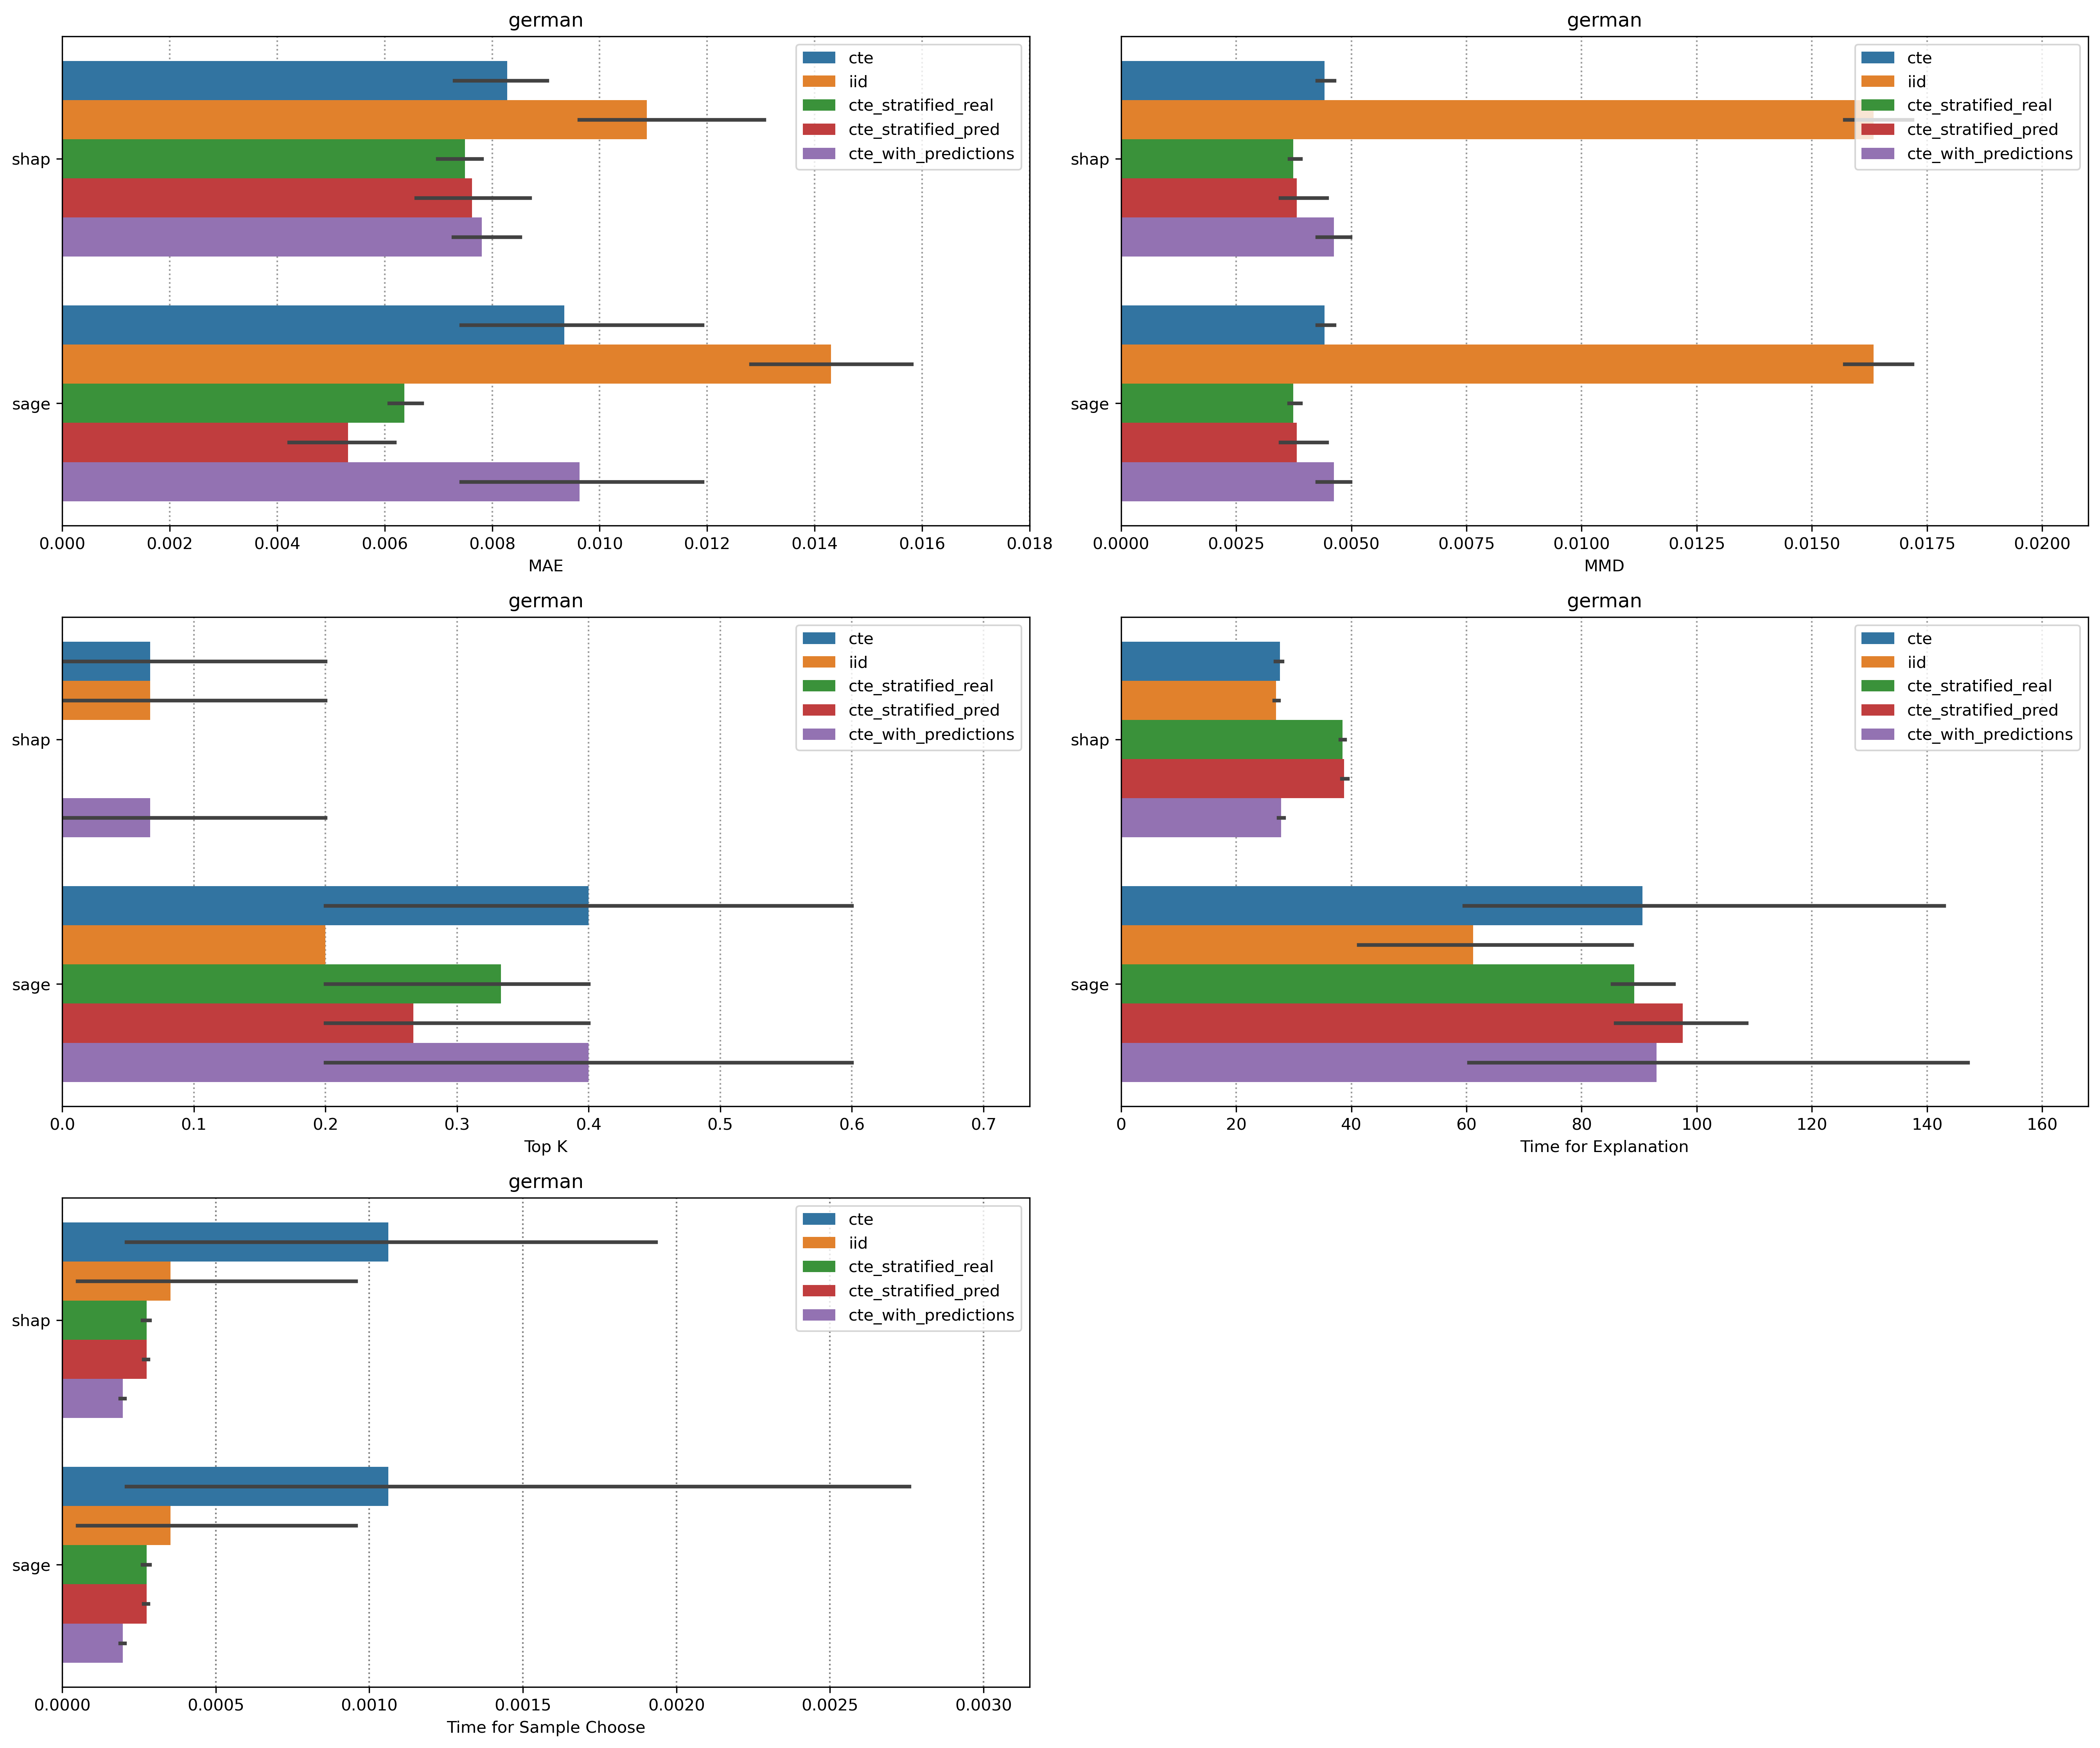

In [81]:
visualize(times_cte_info_german, "german")

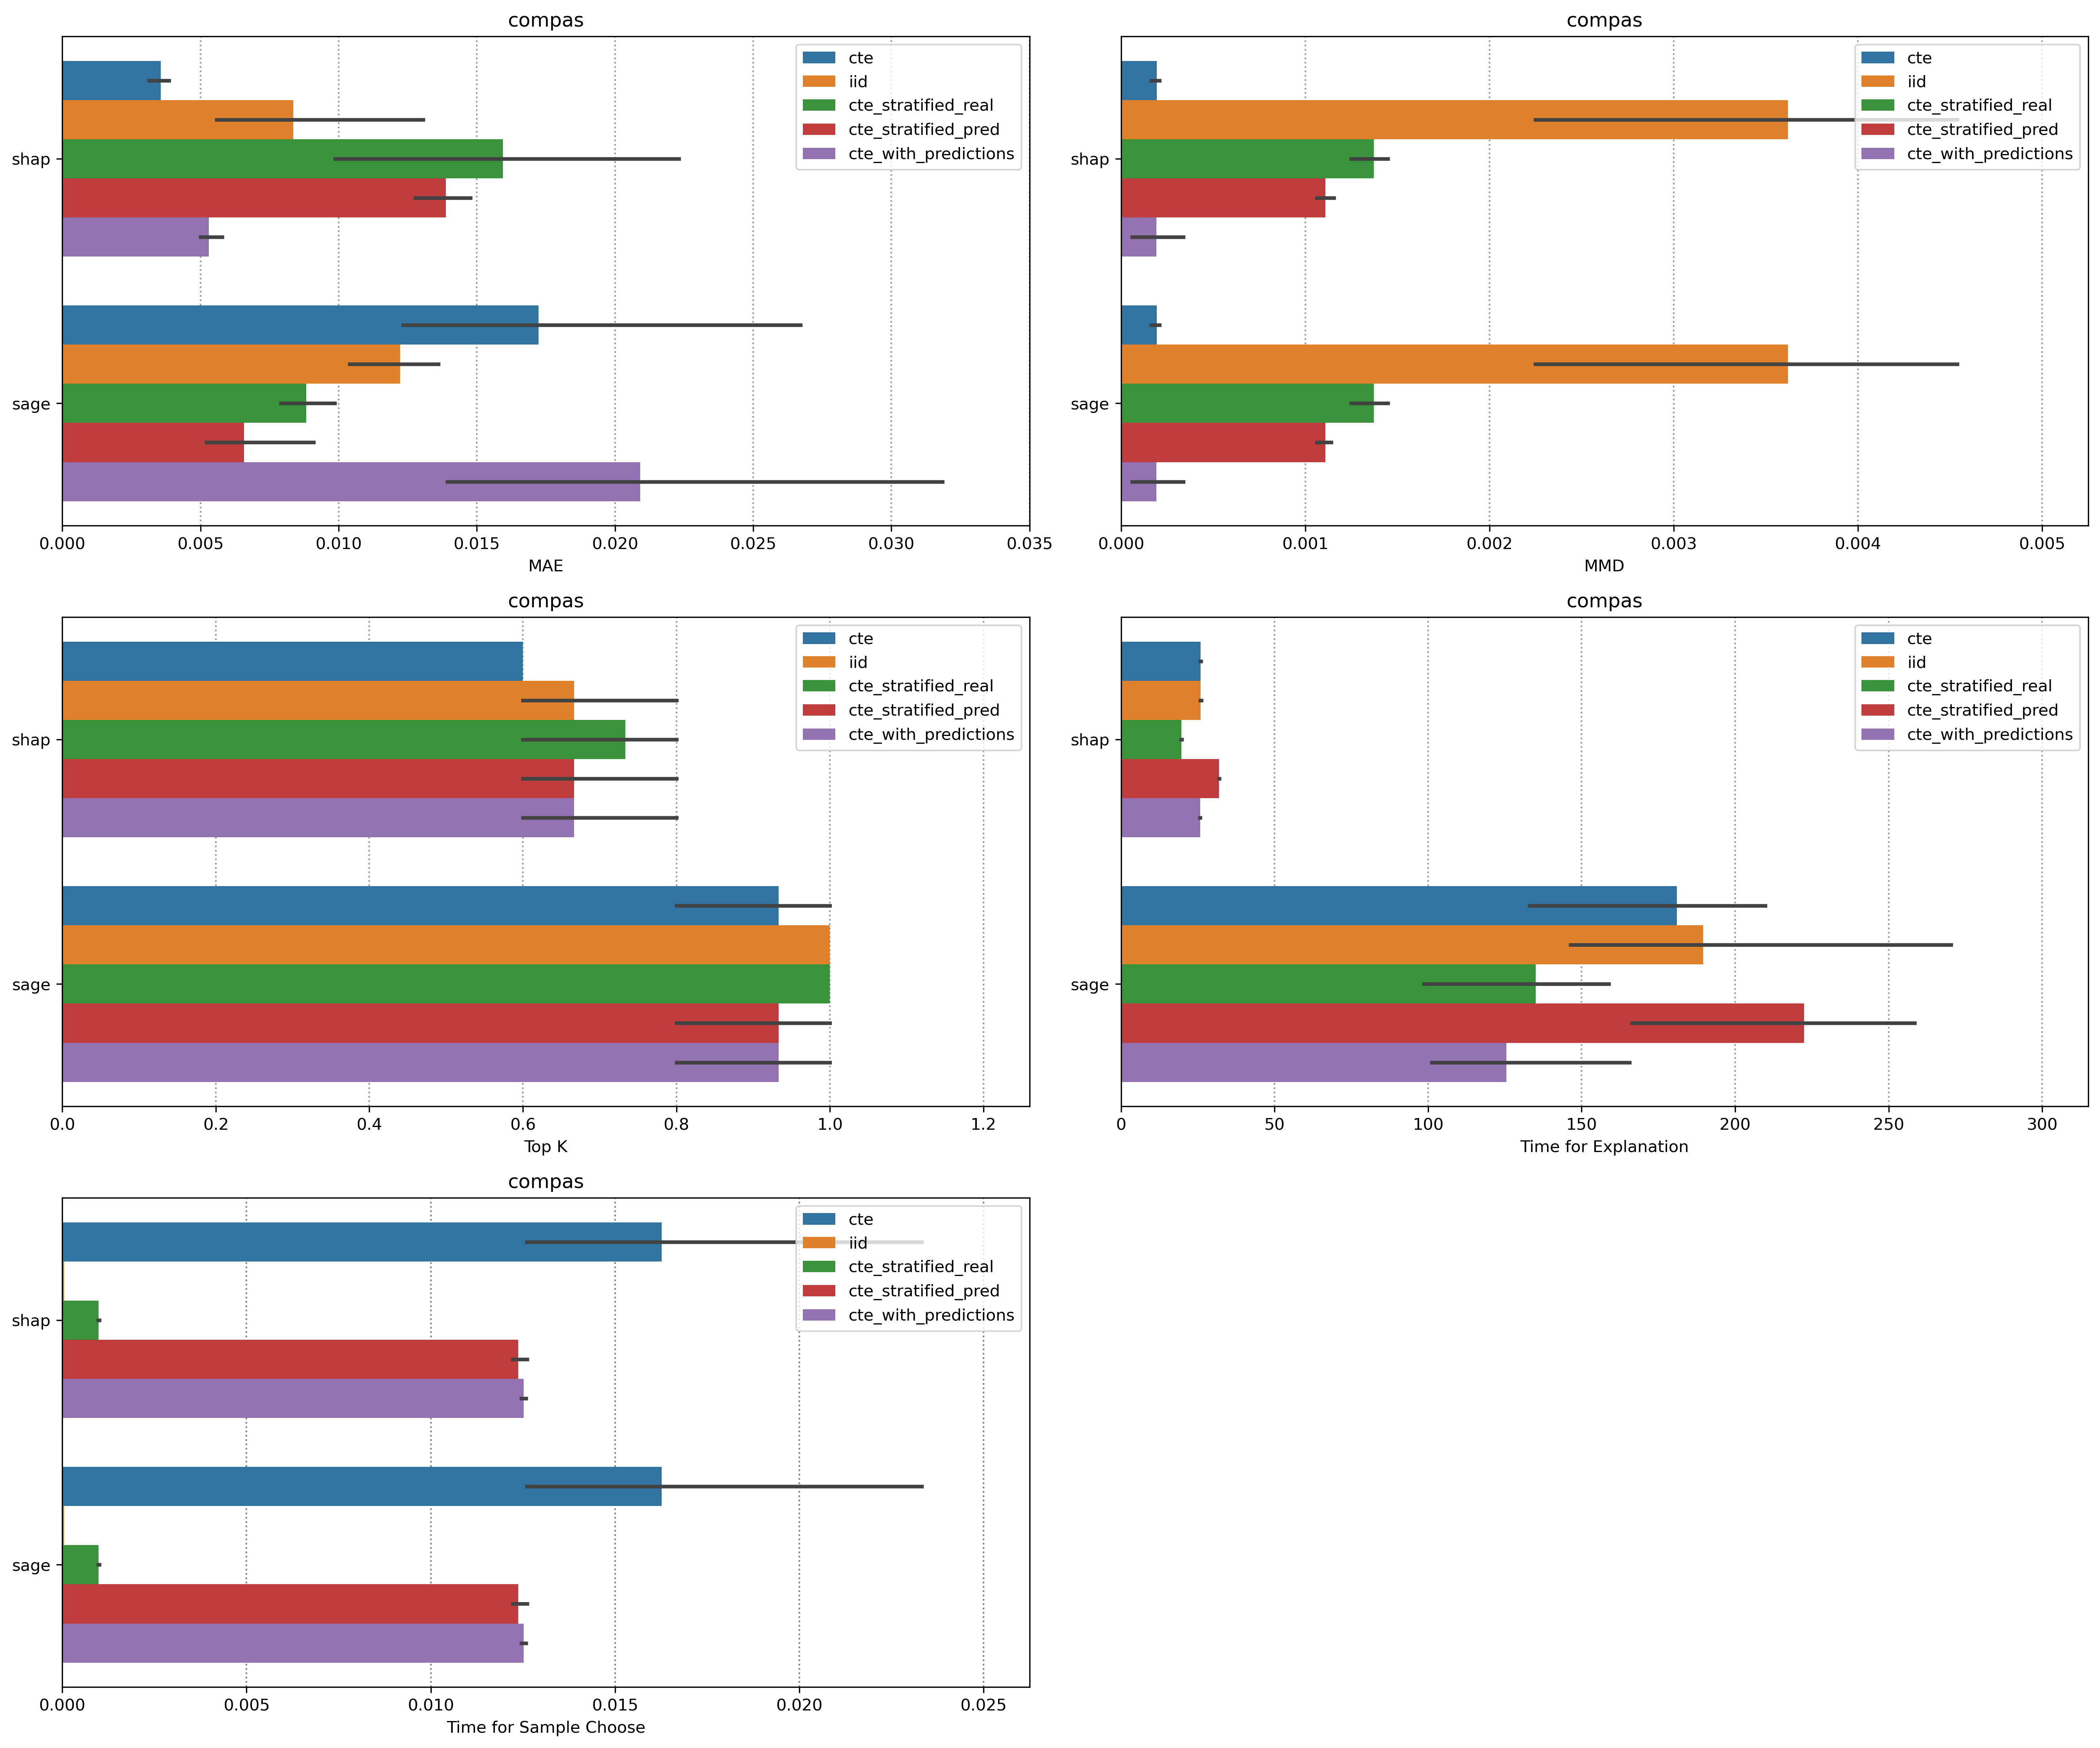

In [82]:
visualize(times_cte_info_compas, "compas")